In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 0. Reconocimiento del dataset

In [2]:
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


### Filas y columnas

In [4]:
mpg.shape

(398, 9)

### Variables numéricas

In [5]:
mpg.select_dtypes(include='number').columns.tolist()

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model_year']

### Valores nulos

In [6]:
mpg.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

### Respuestas

**¿Cuántas filas y columnas tiene el dataset?**  
398 filas y 9 columnas.

**¿Qué variables numéricas contiene?**  
mpg, cylinders, displacement, horsepower, weight, acceleration y model_year (cylinders y model_year se tratan como cualitativas ordinales).

**¿Existen valores nulos? ¿En qué columnas?**  
Sí, 6 en horsepower.

**¿Cuál es la variable que analizaremos?**  
mpg.

## 1. Selección de la variable

In [7]:
variable = "mpg"
datos = mpg[variable]
datos.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

**Variable elegida:** mpg (rendimiento de combustible, millas/galón).

## 2. Medidas descriptivas previas

### Cálculo de medidas

In [8]:
n = datos.count()
minimo = datos.min()
maximo = datos.max()
rango = maximo - minimo
media = datos.mean()
mediana = datos.median()
desv_std = datos.std()
cv = desv_std / media * 100

### Resultados

In [9]:
medidas = pd.DataFrame({
    "Medida": ["n (tamaño de muestra)", "Mínimo", "Máximo", "Rango (R)", "Media (x̄)",
               "Mediana", "Desviación estándar (s)", "Coeficiente de variación (CV %)"],
    "Valor": [n, minimo, maximo, rango, media, mediana, desv_std, cv]
}).round(2)
medidas

,Medida,Valor
0,n (tamaño de muestra),398.00
1,Mínimo,9.00
2,Máximo,46.60
3,Rango (R),37.60
4,Media (x̄),23.51
5,Mediana,23.00
6,Desviación estándar (s),7.82
7,Coeficiente de variación (CV %),33.24


### Interpretación

Se analizaron 398 vehículos cuyo rendimiento va de 9 a 46.6 millas/galón, un rango de 37.6 mpg entre el auto menos y el más eficiente.  
En promedio los vehículos rinden 23.51 mpg y la mitad rinde 23 mpg o menos; como la media es ligeramente mayor que la mediana, hay un leve sesgo a la derecha causado por algunos autos muy eficientes.  
La desviación estándar de 7.82 mpg indica que el rendimiento suele alejarse unas 8 millas/galón del promedio.  
El CV de 33.24 % muestra una dispersión relativa moderada-alta: el dataset reúne vehículos con rendimientos muy distintos.

## 3. Visualización

### Tabla de distribución de frecuencias (regla de Sturges)

In [10]:
import numpy as np

k = int(np.ceil(1 + 3.322 * np.log10(n)))           # número de clases
amplitud = np.ceil(rango / k * 10) / 10             # amplitud redondeada hacia arriba a 1 decimal
limites = np.round(minimo + amplitud * np.arange(k + 1), 1)
print(f"k = {k}, amplitud = {amplitud}")

k = 10, amplitud = 3.8


In [11]:
intervalos = pd.cut(datos, bins=limites, right=False)
tabla = intervalos.value_counts(sort=False).to_frame("fi")
tabla.index.name = "Intervalo"
tabla.insert(0, "xi", [(i.left + i.right) / 2 for i in tabla.index])
tabla["fr"] = tabla["fi"] / n
tabla["fa"] = tabla["fi"].cumsum()
tabla["%"] = tabla["fr"] * 100
tabla["% acumulado"] = tabla["%"].cumsum()
tabla.round(2)

,xi,fi,fr,fa,%,% acumulado
Intervalo,,,,,,
"[9.0, 12.8)",10.9,13,0.03,13,3.27,3.27
"[12.8, 16.6)",14.7,78,0.20,91,19.60,22.86
"[16.6, 20.4)",18.5,74,0.19,165,18.59,41.46
"[20.4, 24.2)",22.3,60,0.15,225,15.08,56.53
"[24.2, 28.0)",26.1,55,0.14,280,13.82,70.35
"[28.0, 31.8)",29.9,48,0.12,328,12.06,82.41
"[31.8, 35.6)",33.7,37,0.09,365,9.30,91.71
"[35.6, 39.4)",37.5,23,0.06,388,5.78,97.49
"[39.4, 43.2)",41.3,5,0.01,393,1.26,98.74


### Histograma

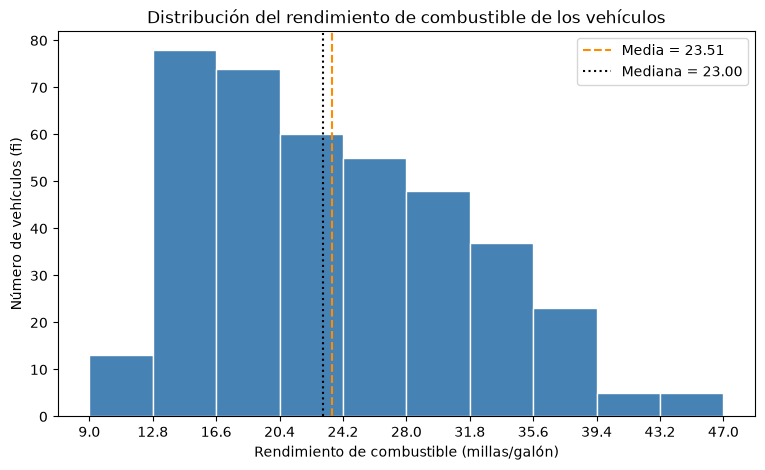

In [12]:
plt.figure(figsize=(9, 5))
plt.hist(datos, bins=limites, color="steelblue", edgecolor="white")
plt.axvline(media, color="darkorange", linestyle="--", label=f"Media = {media:.2f}")
plt.axvline(mediana, color="black", linestyle=":", label=f"Mediana = {mediana:.2f}")
plt.xticks(limites)
plt.xlabel("Rendimiento de combustible (millas/galón)")
plt.ylabel("Número de vehículos (fi)")
plt.title("Distribución del rendimiento de combustible de los vehículos")
plt.legend()
plt.show()

### Gráfico de líneas (porcentaje acumulado)

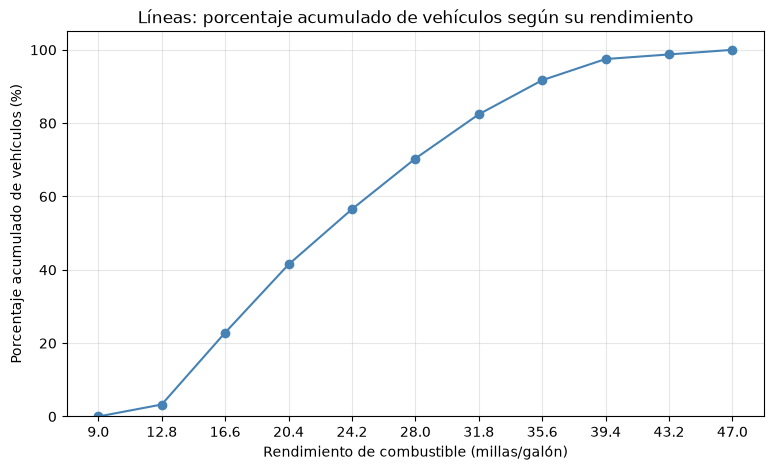

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(limites, [0] + tabla["% acumulado"].tolist(), marker="o", color="steelblue")
plt.xticks(limites)
plt.ylim(0, 105)
plt.xlabel("Rendimiento de combustible (millas/galón)")
plt.ylabel("Porcentaje acumulado de vehículos (%)")
plt.title("Líneas: porcentaje acumulado de vehículos según su rendimiento")
plt.grid(alpha=0.3)
plt.show()

### Forma de la distribución

In [14]:
print(f"Coeficiente de asimetría: {datos.skew():.2f}")
print(f"Intervalo con mayor frecuencia: {tabla['fi'].idxmax()} ({tabla['fi'].max()} vehículos, {tabla['%'].max():.2f} %)")

Coeficiente de asimetría: 0.46
Intervalo con mayor frecuencia: [12.8, 16.6) (78 vehículos, 19.60 %)


In [15]:
q1, q3 = datos.quantile([0.25, 0.75])
ric = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * ric, q3 + 1.5 * ric
print(f"Límites de atípicos (1.5·RIC): [{lim_inf:.2f}, {lim_sup:.2f}]")
print("Valores atípicos:", datos[(datos < lim_inf) | (datos > lim_sup)].tolist())

Límites de atípicos (1.5·RIC): [0.25, 46.25]
Valores atípicos: [46.6]


### Análisis de la forma de la distribución

**¿Es simétrica o sesgada?**  
Sesgada a la derecha (asimetría positiva de 0.46; la media 23.51 es mayor que la mediana 23).

**¿Hacia qué lado se concentra la mayor frecuencia?**  
Hacia la izquierda, en rendimientos bajos: el intervalo [12.8, 16.6) concentra 78 vehículos (19.6 %) y la cola se extiende hacia los valores altos.

**¿Hay valores atípicos visibles?**  
Solo uno: un vehículo con 46.6 mpg, que supera el límite superior de 46.25 mpg.

## 4. Interpretación de resultados

### Intervalo con mayor frecuencia y tercer intervalo

In [16]:
tabla.loc[[tabla["fi"].idxmax(), tabla.index[2]]].round(2)

,xi,fi,fr,fa,%,% acumulado
Intervalo,,,,,,
"[12.8, 16.6)",14.7,78,0.20,91,19.60,22.86
"[16.6, 20.4)",18.5,74,0.19,165,18.59,41.46


### Interpretación

**Contexto de la variable:** mpg mide el rendimiento de combustible, es decir, cuántas millas recorre un vehículo por cada galón; a mayor valor, más eficiente es el auto. Se analizaron 398 vehículos con rendimientos entre 9 y 46.6 mpg.

**Tendencia central:** La media (23.51 mpg) y la mediana (23 mpg) son muy similares, por lo que el rendimiento típico ronda las 23 mpg. La media es ligeramente mayor porque unos pocos autos muy eficientes (cola derecha) la elevan, mientras que la mediana no se ve afectada por esos extremos.

**Dispersión:** La desviación estándar es de 7.82 mpg y el CV de 33.24 %, una variabilidad relativa moderada-alta. El rendimiento no es homogéneo: el dataset reúne vehículos muy distintos entre sí, posiblemente por diferencias de motor, peso y año del modelo.

**Distribución de frecuencias:** El intervalo [12.8, 16.6) concentra más observaciones, con 78 vehículos (19.60 %), seguido de [16.6, 20.4) con 74 (18.59 %). A partir de 20.4 mpg la frecuencia disminuye progresivamente y por encima de 39.4 mpg solo hay 10 vehículos (2.51 %).

**Acumulados:** La fa del tercer intervalo es 165, lo que indica que 165 vehículos (41.46 %) rinden menos de 20.4 mpg; cerca de 4 de cada 10 autos no alcanzan esas 20.4 millas por galón.

**Conclusión general:** La mayoría de los vehículos del dataset tiene un rendimiento bajo a moderado, con una distribución sesgada a la derecha: abundan los autos de 13 a 20 mpg y son pocos los muy eficientes (más de 35 mpg). La alta dispersión sugiere analizar mpg por grupos (cilindros, origen y año) para explicar estas diferencias.

## 5. Preguntas de reflexión

### Comparación 4 vs 8 cilindros (% por intervalo)

In [17]:
grupos = mpg[mpg["cylinders"].isin([4, 8])]
print(grupos["cylinders"].value_counts().sort_index())

comparacion = pd.crosstab(pd.cut(grupos["mpg"], bins=limites, right=False), grupos["cylinders"], normalize="columns") * 100
comparacion.round(2)

cylinders
4    204
8    103
Name: count, dtype: int64


cylinders,4,8
mpg,,
"[9.0, 12.8)",0.00,12.62
"[12.8, 16.6)",0.00,65.05
"[16.6, 20.4)",3.92,19.42
"[20.4, 24.2)",16.67,1.94
"[24.2, 28.0)",24.02,0.97
"[28.0, 31.8)",22.55,0.00
"[31.8, 35.6)",17.65,0.00
"[35.6, 39.4)",10.29,0.00
"[39.4, 43.2)",2.45,0.00


### Respuestas

**¿Qué información aporta la ojiva que no aporta el histograma?**  
La ojiva muestra el porcentaje de vehículos que queda por debajo de cada valor de mpg, lo que permite leer directamente posiciones relativas (mediana, cuartiles, percentiles) y responder preguntas como "¿qué porcentaje rinde menos de 24.2 mpg?" (56.53 %). El histograma solo muestra cuántos vehículos hay en cada intervalo, no cómo se acumulan.

**Si tuviera que comparar dos modelos de autos (p. ej., 4 vs 8 cilindros), ¿cómo usaría las tablas de frecuencia para hacerlo?**  
Construiría una tabla para cada grupo con los mismos intervalos y compararía frecuencias relativas (%) en lugar de absolutas, ya que los grupos tienen distinto tamaño (204 y 103 vehículos). En la tabla anterior, el 65.05 % de los autos de 8 cilindros está en [12.8, 16.6) y ninguno supera 28 mpg, mientras que los de 4 cilindros se concentran entre 24.2 y 31.8 mpg (46.57 %). Las frecuencias acumuladas también ayudan: el 97.09 % de los autos de 8 cilindros rinde menos de 20.4 mpg, frente a solo el 3.92 % de los de 4.

## 6. Análisis comparativo

In [18]:
mpg["origen"] = mpg["origin"].map({"usa": "EE. UU.", "europe": "Europa", "japan": "Japón"})
orden_origen = ["EE. UU.", "Europa", "Japón"]
colores_origen = {"EE. UU.": "#66c2a5", "Europa": "#fc8d62", "Japón": "#8da0cb"}

### Pregunta 1: ¿Existen diferencias en el rendimiento (mpg) según el número de cilindros?

In [19]:
mpg.groupby("cylinders")["mpg"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
cylinders,,,,,,,,
3,4.0,20.55,2.56,18.0,18.75,20.25,22.05,23.7
4,204.0,29.29,5.71,18.0,25.00,28.25,33.00,46.6
5,3.0,27.37,8.23,20.3,22.85,25.40,30.90,36.4
6,84.0,19.99,3.81,15.0,18.00,19.00,21.00,38.0
8,103.0,14.96,2.84,9.0,13.00,14.00,16.00,26.6


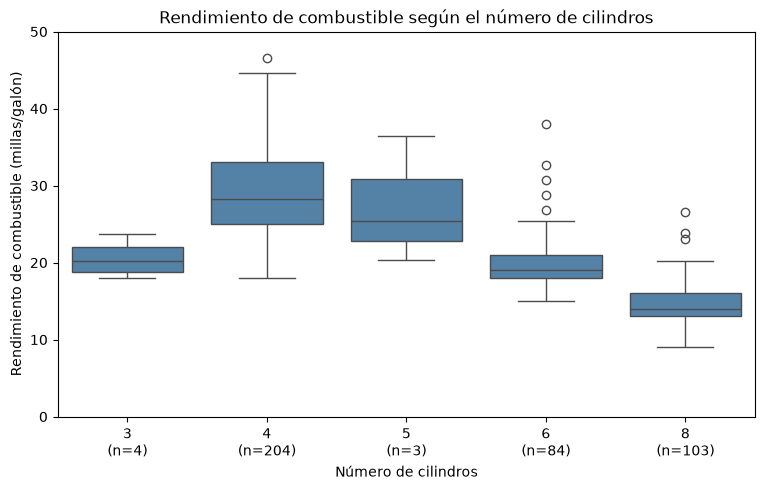

In [20]:
conteo_cil = mpg["cylinders"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.boxplot(x="cylinders", y="mpg", data=mpg, color="steelblue")
plt.xticks(range(len(conteo_cil)), [f"{c}\n(n={n})" for c, n in conteo_cil.items()])
plt.ylim(0, 50)
plt.xlabel("Número de cilindros")
plt.ylabel("Rendimiento de combustible (millas/galón)")
plt.title("Rendimiento de combustible según el número de cilindros")
plt.show()

### Respuestas

**¿Cómo varía la mediana de mpg al aumentar el número de cilindros?**  
Disminuye de forma marcada a partir de 4 cilindros: 28.25 mpg (4), 25.4 (5), 19 (6) y 14 (8). Los autos de 3 cilindros (mediana 20.25) rompen la tendencia, pero son solo 4 Mazda RX con motor rotativo.

**¿Qué grupo presenta mayor dispersión? ¿A qué podría deberse?**  
Entre los grupos con suficientes datos, el de 4 cilindros (s = 5.71, RIC = 8). Es el grupo más numeroso (204) y más variado: incluye autos de los tres orígenes, de todos los años y algunos diésel muy eficientes. El de 5 cilindros tiene s = 8.23, pero con solo 3 autos no es representativo.

**¿Hay solapamiento entre las cajas? ¿Qué implica estadísticamente?**  
Las cajas de 4, 6 y 8 cilindros no se solapan (Q1 de 4 cil. = 25 > Q3 de 6 cil. = 21; Q1 de 6 cil. = 18 > Q3 de 8 cil. = 16), lo que sugiere diferencias reales entre sus medianas. Las de 3 y 5 cilindros sí se solapan con otras, pero su tamaño no permite sacar conclusiones.

**Formula una hipótesis que luego podrías contrastar con ANOVA.**  
H₀: el rendimiento medio es igual en los grupos de 4, 6 y 8 cilindros (μ₄ = μ₆ = μ₈).  
H₁: al menos un grupo tiene un rendimiento medio distinto.

**Interpretación técnica:**  
El número de cilindros tiene una relación inversa clara con el rendimiento: al pasar de 4 a 8 cilindros la media cae de 29.29 a 14.96 mpg. Los grupos de 6 y 8 cilindros son más homogéneos (s = 3.81 y 2.84), pero presentan asimetría a la derecha con atípicos altos. Los grupos de 3 y 5 cilindros deberían excluirse o agruparse en un análisis inferencial por su tamaño muestral.

### Pregunta 2: ¿Existen diferencias significativas en el rendimiento según el país de origen (origin)?

In [21]:
resumen_origen = mpg.groupby("origen")["mpg"].describe()
resumen_origen["varianza"] = mpg.groupby("origen")["mpg"].var()
resumen_origen["asimetría"] = mpg.groupby("origen")["mpg"].skew()
resumen_origen.loc[orden_origen].round(2)

,count,mean,std,min,25%,50%,75%,max,varianza,asimetría
origen,,,,,,,,,,
EE. UU.,249.0,20.08,6.40,9.0,15.0,18.5,24.00,39.0,41.00,0.82
Europa,70.0,27.89,6.72,16.2,24.0,26.5,30.65,44.3,45.21,0.70
Japón,79.0,30.45,6.09,18.0,25.7,31.6,34.05,46.6,37.09,0.01


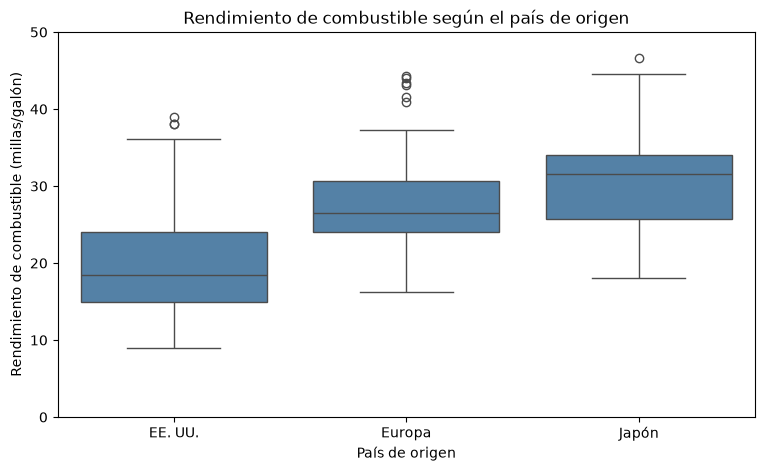

In [22]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="origen", y="mpg", data=mpg, order=orden_origen, color="steelblue")
plt.ylim(0, 50)
plt.xlabel("País de origen")
plt.ylabel("Rendimiento de combustible (millas/galón)")
plt.title("Rendimiento de combustible según el país de origen")
plt.show()

### Posibles variables de confusión

In [23]:
mpg.groupby("origen")[["weight", "horsepower", "displacement"]].mean().loc[orden_origen].round(1)

,weight,horsepower,displacement
origen,,,
EE. UU.,3361.9,119.0,245.9
Europa,2423.3,80.6,109.1
Japón,2221.2,79.8,102.7


In [24]:
pd.crosstab(mpg["origen"], mpg["cylinders"]).loc[orden_origen]

cylinders,3,4,5,6,8
origen,,,,,
EE. UU.,0,72,0,74,103
Europa,0,63,3,4,0
Japón,4,69,0,6,0


### Respuestas

**¿Qué origen tiene mejor rendimiento promedio? ¿Y peor?**  
Mejor: Japón (30.45 mpg). Peor: EE. UU. (20.08 mpg). Europa queda en medio (27.89 mpg).

**¿La forma de las distribuciones es similar entre orígenes?**  
No del todo. EE. UU. (asimetría 0.82) y Europa (0.70) están sesgadas a la derecha, con la media por encima de la mediana; Japón es prácticamente simétrica (0.01).

**¿Los datos sugieren igualdad de varianzas entre grupos?**  
Sí. Las desviaciones estándar son parecidas (6.40, 6.72 y 6.09) y la varianza mayor (Europa, 45.21) es solo 1.22 veces la menor (Japón, 37.09).

**¿Qué otros factores podrían estar confundiendo la comparación (variables de confusión)?**  
El peso, la potencia, la cilindrada y el número de cilindros. Los autos de EE. UU. pesan en promedio 3,362 lb frente a unas 2,200–2,400 lb de Europa y Japón, tienen más del doble de cilindrada y son los únicos con 8 cilindros (103 autos). Parte de la diferencia por origen se debe al tipo de vehículo que fabrica cada región.

**Interpretación técnica:**  
Descriptivamente sí hay diferencias marcadas: existe una diferencia de más de 10 mpg entre las medias de Japón y EE. UU., y la caja de EE. UU. (Q3 = 24) queda casi por debajo de las de Europa y Japón. Como las varianzas son similares, el supuesto de homocedasticidad de un ANOVA parece razonable. Sin embargo, la comparación no es directa, porque el origen está muy asociado al tamaño del motor y al peso del vehículo. Confirmar que la diferencia es estadísticamente significativa requiere un ANOVA.

### Pregunta 3: ¿Cómo interactúan el origen y el número de cilindros sobre el rendimiento?

In [25]:
mpg.pivot_table(index="cylinders", columns="origen", values="mpg", aggfunc="mean")[orden_origen].round(2)

origen,EE. UU.,Europa,Japón
cylinders,,,
3,NaN,NaN,20.55
4,27.84,28.41,31.60
5,NaN,27.37,NaN
6,19.66,20.10,23.88
8,14.96,NaN,NaN


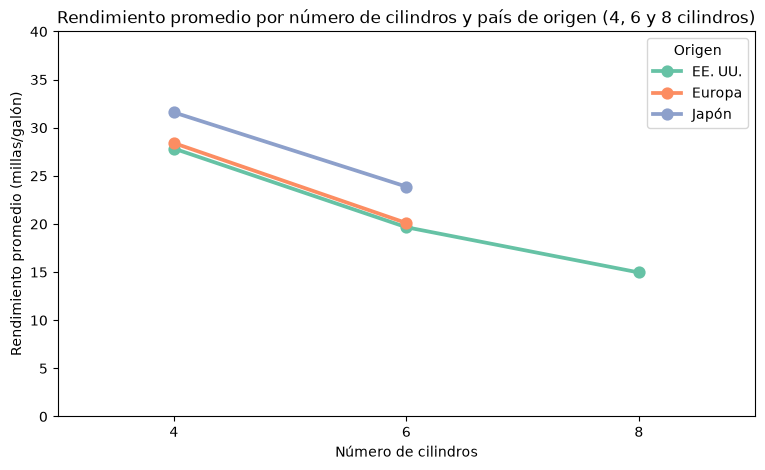

In [26]:
principales = mpg[mpg["cylinders"].isin([4, 6, 8])]  # se excluyen 3 y 5 cilindros (n = 4 y n = 3)

plt.figure(figsize=(9, 5))
sns.pointplot(x="cylinders", y="mpg", hue="origen", hue_order=orden_origen, data=principales, errorbar=None, palette=colores_origen)
plt.ylim(0, 40)
plt.xlabel("Número de cilindros")
plt.ylabel("Rendimiento promedio (millas/galón)")
plt.title("Rendimiento promedio por número de cilindros y país de origen (4, 6 y 8 cilindros)")
plt.legend(title="Origen")
plt.show()

### Respuestas

**¿El efecto de los cilindros sobre mpg es constante entre orígenes?**  
Casi constante. De 4 a 6 cilindros el rendimiento cae 8.18 mpg en EE. UU., 8.31 en Europa y 7.72 en Japón; las líneas son prácticamente paralelas, por lo que la interacción es débil.

**¿Algún origen tiene un comportamiento diferenciado?**  
Japón: con el mismo número de cilindros rinde entre 3.2 y 4.2 mpg más que EE. UU. y Europa (31.60 vs. 27.84 y 28.41 con 4 cilindros; 23.88 vs. 19.66 y 20.10 con 6). Además, sus autos de 3 cilindros (Mazda RX con motor rotativo, excluidos del gráfico por ser solo 4) rinden menos que los de 4. EE. UU. es el único origen con autos de 8 cilindros.

**¿Qué ventajas tiene este gráfico respecto a los anteriores?**  
Muestra dos factores a la vez y permite separar sus efectos. Con 4 cilindros, la diferencia entre EE. UU. y Europa casi desaparece (27.84 vs. 28.41 mpg), lo que revela que gran parte de la brecha de la Pregunta 2 se explica por el número de cilindros y no por el origen.

**Interpretación técnica:**  
El número de cilindros es el factor dominante sobre el rendimiento y su efecto es similar en los tres orígenes. El origen tiene un efecto menor, pero consistente, a favor de Japón, aunque las medias de 6 cilindros de Europa (4 autos) y Japón (6 autos) se basan en pocos datos. Un ANOVA de dos factores debería considerar que el diseño está desbalanceado y que faltan combinaciones (Europa y Japón no tienen 8 cilindros).

### Pregunta 4: ¿Cómo ha cambiado la composición de cilindros y orígenes por año?

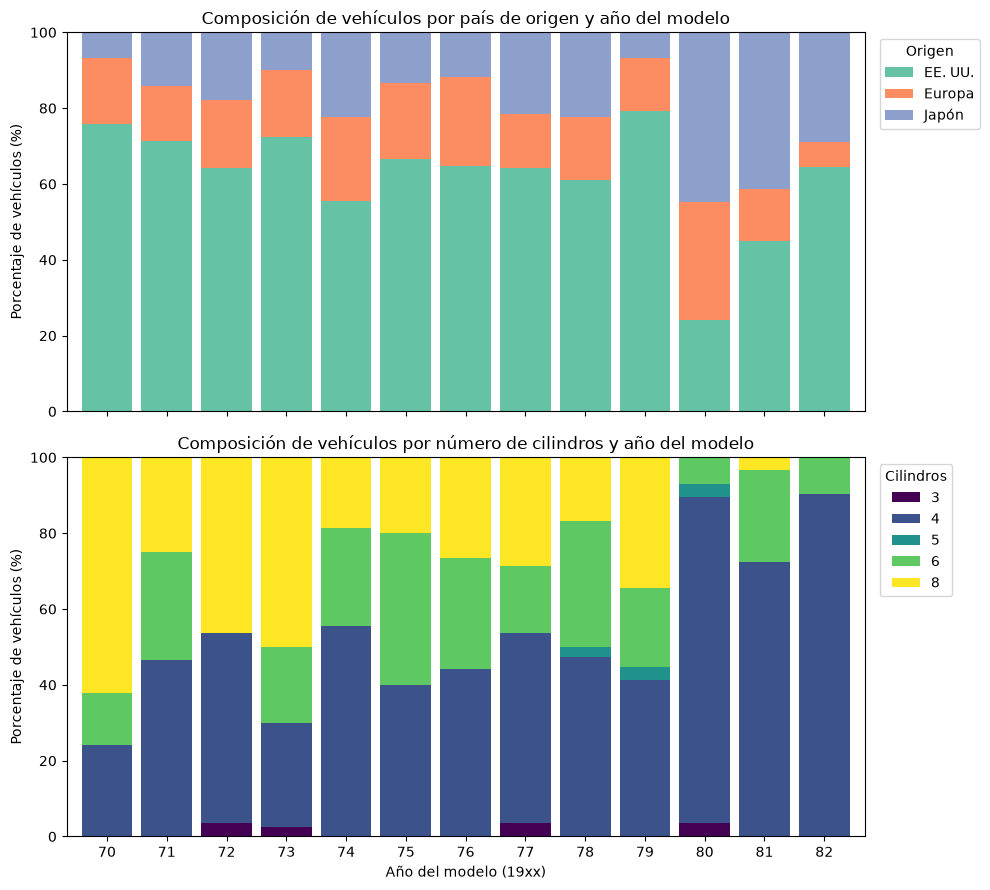

In [27]:
comp_origen = pd.crosstab(mpg["model_year"], mpg["origen"], normalize="index")[orden_origen] * 100
comp_cilindros = pd.crosstab(mpg["model_year"], mpg["cylinders"], normalize="index") * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
comp_origen.plot(kind="bar", stacked=True, ax=axes[0], color=colores_origen, width=0.85)
axes[0].set_title("Composición de vehículos por país de origen y año del modelo")
axes[0].set_ylabel("Porcentaje de vehículos (%)")
axes[0].legend(title="Origen", bbox_to_anchor=(1.01, 1), loc="upper left")

comp_cilindros.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", width=0.85)
axes[1].set_title("Composición de vehículos por número de cilindros y año del modelo")
axes[1].set_ylabel("Porcentaje de vehículos (%)")
axes[1].set_xlabel("Año del modelo (19xx)")
axes[1].legend(title="Cilindros", bbox_to_anchor=(1.01, 1), loc="upper left")

for ax in axes:
    ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
comp_origen.round(1)

origen,EE. UU.,Europa,Japón
model_year,,,
70,75.9,17.2,6.9
71,71.4,14.3,14.3
72,64.3,17.9,17.9
73,72.5,17.5,10.0
74,55.6,22.2,22.2
75,66.7,20.0,13.3
76,64.7,23.5,11.8
77,64.3,14.3,21.4
78,61.1,16.7,22.2


In [29]:
comp_cilindros.round(1)

cylinders,3,4,5,6,8
model_year,,,,,
70,0.0,24.1,0.0,13.8,62.1
71,0.0,46.4,0.0,28.6,25.0
72,3.6,50.0,0.0,0.0,46.4
73,2.5,27.5,0.0,20.0,50.0
74,0.0,55.6,0.0,25.9,18.5
75,0.0,40.0,0.0,40.0,20.0
76,0.0,44.1,0.0,29.4,26.5
77,3.6,50.0,0.0,17.9,28.6
78,0.0,47.2,2.8,33.3,16.7


In [30]:
mpg.groupby("model_year")["mpg"].mean().round(2)

model_year
70    17.69
71    21.25
72    18.71
73    17.10
74    22.70
75    20.27
76    21.57
77    23.38
78    24.06
79    25.09
80    33.70
81    30.33
82    31.71
Name: mpg, dtype: float64

### Respuestas

**¿Cómo ha evolucionado la participación de cada origen por año?**  
EE. UU. domina de 1970 a 1979 (entre 55.6 % y 79.3 %), pero cae a 24.1 % en 1980 y 44.8 % en 1981, para recuperarse a 64.5 % en 1982. Japón pasa de 6.9 % en 1970 a 44.8 % en 1980 y 41.4 % en 1981. Europa se mantiene entre 13.8 % y 23.5 %, salvo un pico de 31 % en 1980 y su mínimo en 1982 (6.5 %).

**¿Disminuyó la presencia de vehículos con 8 cilindros con los años?**  
Sí. Pasó de 62.1 % en 1970 a 0 % en 1980 y 1982 (3.4 % en 1981). Al mismo tiempo, los de 4 cilindros crecieron de 24.1 % a 90.3 %.

**¿Qué relación encuentras entre este gráfico y la tendencia de mpg del Bloque I?**  
El rendimiento promedio sube de 17.69 mpg en 1970 a 33.70 mpg en 1980 y se mantiene por encima de 30 mpg hasta 1982. Este aumento coincide con la desaparición de los autos de 8 cilindros y el crecimiento de los de 4 cilindros y de los japoneses, que son los más eficientes según las preguntas anteriores.

**Interpretación técnica:**  
La composición del dataset cambia mucho con el tiempo: los autos más recientes tienen menos cilindros y hay mayor participación japonesa. El salto más fuerte ocurre a partir de 1980, cuando los de 8 cilindros prácticamente desaparecen. Esto implica que el año del modelo también es una variable de confusión: parte de las diferencias por cilindros y origen podría deberse a la época de fabricación.

## 7. Diseño de su propio análisis

### Pregunta: ¿Cómo se relaciona el peso del vehículo con su rendimiento y cambia esta relación según el país de origen?

In [31]:
def tendencia(g):
    pendiente, intercepto = np.polyfit(g["weight"], g["mpg"], 1)
    return pd.Series({
        "n": len(g),
        "r (peso vs mpg)": g["weight"].corr(g["mpg"]),
        "Cambio en mpg por cada 1000 lb": pendiente * 1000,
        "mpg estimado a 2500 lb": intercepto + pendiente * 2500,
        "Peso mínimo (lb)": g["weight"].min(),
        "Peso máximo (lb)": g["weight"].max(),
    })

relacion = mpg.groupby("origen")[["weight", "mpg"]].apply(tendencia).loc[orden_origen]
relacion.loc["Total"] = tendencia(mpg)
relacion.round(2)

,n,r (peso vs mpg),Cambio en mpg por cada 1000 lb,mpg estimado a 2500 lb,Peso mínimo (lb),Peso máximo (lb)
origen,,,,,,
EE. UU.,249.0,-0.85,-6.81,25.96,1800.0,5140.0
Europa,70.0,-0.53,-7.22,27.34,1825.0,3820.0
Japón,79.0,-0.56,-10.72,27.46,1613.0,2930.0
Total,398.0,-0.83,-7.68,27.13,1613.0,5140.0


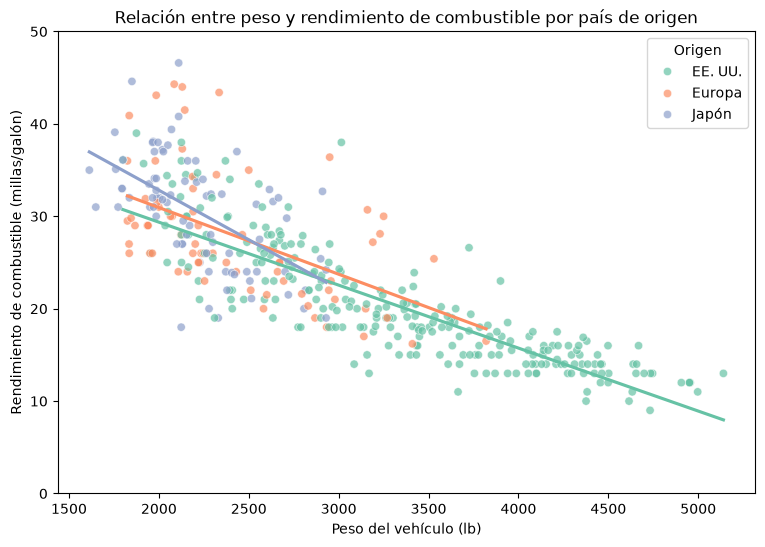

In [32]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x="weight", y="mpg", hue="origen", hue_order=orden_origen, data=mpg, palette=colores_origen, alpha=0.7)
for origen in orden_origen:
    sns.regplot(x="weight", y="mpg", data=mpg[mpg["origen"] == origen], scatter=False, ci=None, color=colores_origen[origen])
plt.ylim(0, 50)
plt.xlabel("Peso del vehículo (lb)")
plt.ylabel("Rendimiento de combustible (millas/galón)")
plt.title("Relación entre peso y rendimiento de combustible por país de origen")
plt.legend(title="Origen")
plt.show()

### Respuestas

**Pregunta de análisis propuesta:**  
¿Cómo se relaciona el peso del vehículo con su rendimiento y cambia esta relación según el país de origen?

**Variables involucradas:**  
Eje X: weight (peso del vehículo, lb)  
Eje Y: mpg (rendimiento de combustible, millas/galón)  
Color/grupo: origin (país de origen)

**Tipo de gráfico seleccionado y justificación:**  
Diagrama de dispersión con una recta de tendencia por origen. Peso y mpg son variables cuantitativas continuas, por lo que la dispersión es el gráfico adecuado para ver la forma y fuerza de su relación. El color por origen y las rectas permiten comparar la tendencia entre grupos y ver si la diferencia de rendimiento entre orígenes se mantiene a igual peso.

**Interpretación técnica:**  
Existe una relación negativa fuerte entre peso y rendimiento (r = −0.83): en promedio, cada 1000 lb adicionales reducen el rendimiento en unas 7.7 mpg.  
La relación es más fuerte en EE. UU. (r = −0.85), que también tiene el mayor rango de pesos (1,800 a 5,140 lb), y más moderada en Europa (−0.53) y Japón (−0.56).  
Los autos japoneses son los más sensibles al peso (−10.72 mpg por cada 1000 lb), aunque ninguno supera las 2,930 lb.  
A un mismo peso de 2,500 lb, el rendimiento estimado es muy parecido entre orígenes: 25.96 mpg en EE. UU., 27.34 en Europa y 27.46 en Japón.  
Es decir, la brecha de más de 10 mpg observada en la Pregunta 2 se reduce a unos 1.5 mpg al comparar autos de peso similar.  
Esto confirma que el peso es una variable de confusión importante: los autos estadounidenses rinden menos principalmente porque son más pesados, no solo por su origen.  
La nube de puntos muestra además cierta curvatura (el rendimiento cae más rápido en pesos bajos), por lo que un modelo no lineal podría ajustarse mejor.

## Matriz de autoevaluación de los gráficos

In [33]:
graficos = ["Histograma", "Líneas (% acumulado)", "P1 Cilindros", "P2 Origen", "P3 Interacción", "P4 Composición", "P7 Peso vs mpg"]
criterios = [
    "El título describe qué se muestra",
    "Los ejes tienen etiquetas con unidades",
    "La escala del eje Y comienza en cero (cuando aplica)",
    "El uso del color es informativo, no decorativo",
    "Se incluye leyenda cuando hay múltiples grupos",
    "No hay chartjunk",
    "El tipo de gráfico corresponde a la naturaleza de las variables",
]
evaluacion = [
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
    ["✔", "N/A", "N/A", "N/A", "✔", "✔", "✔"],
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
    ["✔", "✔", "✔", "✔", "✔", "✔", "✔"],
]
comentarios = [
    "Cada título indica la variable y la comparación que se muestra.",
    "mpg en millas/galón, peso en lb, frecuencias en número de vehículos o %; cilindros y origen no tienen unidad.",
    "Todos los ejes Y inician en 0, incluidos boxplots, líneas y dispersión.",
    "Un solo color cuando no hay grupos; el color distingue media/mediana, origen o cilindros (escala ordinal).",
    "N/A: gráfico de líneas y boxplots de P1 y P2 tienen una sola serie o los grupos están en el eje X.",
    "Sin fondos, 3D ni efectos; el gráfico de líneas solo tiene una cuadrícula tenue para facilitar la lectura.",
    "Histograma y líneas de % acumulado para una variable continua, boxplots para grupos, líneas para interacción, barras apiladas para composición y dispersión para dos continuas.",
]
matriz = pd.DataFrame(evaluacion, index=criterios, columns=graficos)
matriz["Comentario"] = comentarios
matriz

,Histograma,Líneas (% acumulado),P1 Cilindros,P2 Origen,P3 Interacción,P4 Composición,P7 Peso vs mpg,Comentario
El título describe qué se muestra,✔,✔,✔,✔,✔,✔,✔,Cada título indica la variable y la comparació...
Los ejes tienen etiquetas con unidades,✔,✔,✔,✔,✔,✔,✔,"mpg en millas/galón, peso en lb, frecuencias e..."
La escala del eje Y comienza en cero (cuando aplica),✔,✔,✔,✔,✔,✔,✔,"Todos los ejes Y inician en 0, incluidos boxpl..."
"El uso del color es informativo, no decorativo",✔,✔,✔,✔,✔,✔,✔,Un solo color cuando no hay grupos; el color d...
Se incluye leyenda cuando hay múltiples grupos,✔,N/A,N/A,N/A,✔,✔,✔,N/A: gráfico de líneas y boxplots de P1 y P2 t...
No hay chartjunk,✔,✔,✔,✔,✔,✔,✔,"Sin fondos, 3D ni efectos; el gráfico de línea..."
El tipo de gráfico corresponde a la naturaleza de las variables,✔,✔,✔,✔,✔,✔,✔,Histograma y líneas de % acumulado para una va...
